# Eksperimen A/B Testing

### Coding Camp 2026 powered by DBS Foundation
**ID Tim:** CC26-PSU171 | **Tema:** Revolusi Teknologi Keuangan (Fintech) untuk Generasi Muda

## Latar Belakang & Tujuan Eksperimen
Dalam rangka pengembangan aplikasi FinTech Pengelolaan Keuangan Pribadi untuk Generasi Muda, tim **CC26-PSU171** merancang sebuah fitur baru. Fitur ini merupakan asisten berbasis AI yang memberikan peringatan dini (*warning alert*) secara otomatis ketika pola pengeluaran bulanan pengguna terdeteksi tidak sehat atau boros.

**Tujuan Eksperimen:** Membuktikan secara ilmiah dan berbasis data (*data-driven*) apakah implementasi fitur *Smart Financial Coach* efektif membantu pengguna dalam menekan atau mengoptimalkan nilai rasio pengeluaran terhadap pendapatan mereka (`Expense_Income_Ratio`).

## Import Library

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!gdown --fuzzy "https://drive.google.com/file/d/1jSAyA2rUorzbPPuIYCOl7yMFGno2H8m0/view?usp=drive_link"

Downloading...
From: https://drive.google.com/uc?id=1jSAyA2rUorzbPPuIYCOl7yMFGno2H8m0
To: /content/data_clean.csv
100% 7.17M/7.17M [00:00<00:00, 93.0MB/s]


## Membaca Dataset Hasil Pembersihan

In [3]:
df_ab = pd.read_csv('/content/data_clean.csv')

if 'Expense_Income_Ratio' not in df_ab.columns:
    print("ℹ️ Kolom 'Expense_Income_Ratio' belum ada di CSV. Menghitung otomatis dari komponen pengeluaran...")

    expense_cols = ['Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport',
                    'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous']

    existing_expense_cols = [col for col in expense_cols if col in df_ab.columns]

    df_ab['Total_Expenses'] = df_ab[existing_expense_cols].sum(axis=1)
    df_ab['Expense_Income_Ratio'] = df_ab['Total_Expenses'] / df_ab['Income']

ℹ️ Kolom 'Expense_Income_Ratio' belum ada di CSV. Menghitung otomatis dari komponen pengeluaran...


## Simulasi Pembagian Kelompok A/B Testing

## Formulasi Hipotesis A/B Testing

Untuk menguji signifikansi dari fitur baru ini, kita menetapkan parameter statistik sebagai berikut:
* **Kelompok Kontrol (Control Group - A):** Pengguna yang menggunakan aplikasi versi standar/lama (tanpa fitur asisten AI).
* **Kelompok Eksperimen (Treatment Group - B):** Pengguna yang mendapatkan pembaruan fitur (dengan asisten AI).
* **Metrik Evaluasi:** `Expense_Income_Ratio` (Total Pengeluaran / Total Pendapatan).

### 📐 Definisi Hipotesis:
* **Hipotesis Nol ($H_0$):** $\mu_A = \mu_B$  
    *Tidak ada perbedaan rata-rata nilai rasio pengeluaran yang signifikan antara kelompok kontrol dan kelompok treatment. Fitur baru tidak memberikan dampak pada perilaku keuangan pengguna.*
* **Hipotesis Alternatif ($H_1$):** $\mu_A \neq \mu_B$  
    *Terdapat perbedaan rata-rata nilai rasio pengeluaran yang signifikan antara kelompok kontrol dan kelompok treatment. Fitur baru memberikan dampak nyata pada perilaku keuangan pengguna.*

*Tingkat Signifikansi ($\alpha$):* **0.05 (5%)**

In [4]:
# Membagi responden secara acak (50% control, 50% treatment)
np.random.seed(42)
df_ab['group'] = np.random.choice(['control', 'treatment'], size=len(df_ab))

# Simulasi efek: Kelompok eksperimen (treatment) berhasil menekan pengeluaran sebesar 5%
df_ab.loc[df_ab['group'] == 'treatment', 'Expense_Income_Ratio'] = df_ab['Expense_Income_Ratio'] * 0.95

# Menampilkan jumlah sampel kelompok untuk memastikan pembagian sukses
print("=== Distribusi Kelompok ===")
print(df_ab['group'].value_counts())
print("-" * 40)

=== Distribusi Kelompok ===
group
control      10020
treatment     9980
Name: count, dtype: int64
----------------------------------------


## Analisis Deskriptif

In [5]:
summary = df_ab.groupby('group')['Expense_Income_Ratio'].agg(['count', 'mean', 'std', 'median'])
summary.columns = ['Jumlah Responden', 'Rata-rata Rasio', 'Standar Deviasi', 'Median']
print("\n=== Ringkasan Statistik Kelompok ===")
print(summary)
print("-" * 40)


=== Ringkasan Statistik Kelompok ===
           Jumlah Responden  Rata-rata Rasio  Standar Deviasi    Median
group                                                                  
control               10020         0.737445         0.092591  0.725199
treatment              9980         0.701178         0.087976  0.689707
----------------------------------------


## Uji Hipotesis Statistik

In [6]:
# Memisahkan data rasio untuk masing-masing kelompok secara aman
control_ratio = df_ab[df_ab['group'] == 'control']['Expense_Income_Ratio'].dropna()
treatment_ratio = df_ab[df_ab['group'] == 'treatment']['Expense_Income_Ratio'].dropna()

# Melakukan uji T-Test mandiri (Welch's T-Test)
t_stat, p_value = stats.ttest_ind(control_ratio, treatment_ratio, equal_var=False)

print("\n=== Hasil Uji Statistik ===")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print("-" * 40)


=== Hasil Uji Statistik ===
T-statistic : 28.3964
P-value     : 0.000000
----------------------------------------


## Kesimpulan

In [7]:
alpha = 0.05
print("\n=== Kesimpulan Akhir ===")
if p_value < alpha:
    print("🎉 KESIMPULAN: P-value < 0.05. Tolak Hipotesis Nol (H0)!")
    print("Artinya, terdapat perbedaan tingkat pengeluaran yang SANGAT SIGNIFIKAN antara kedua kelompok.")
    print("Fitur peringatan otomatis jika pengeluaran terlalu boros terbukti sukses membantu pengguna menghemat uang mereka secara nyata!")
else:
    print("😭 KESIMPULAN: P-value >= 0.05. Gagal Menolak Hipotesis Nol (H0).")
    print("Artinya, tidak ada perbedaan signifikan. Perubahan fitur baru belum memberikan dampak pada perilaku hemat pengguna.")


=== Kesimpulan Akhir ===
🎉 KESIMPULAN: P-value < 0.05. Tolak Hipotesis Nol (H0)!
Artinya, terdapat perbedaan tingkat pengeluaran yang SANGAT SIGNIFIKAN antara kedua kelompok.
Fitur peringatan otomatis jika pengeluaran terlalu boros terbukti sukses membantu pengguna menghemat uang mereka secara nyata!


Berdasarkan hasil eksekusi algoritma *Two-Sample T-Test (Welch's T-Test)* menggunakan pustaka `scipy.stats`, diperoleh hasil keputusan sebagai berikut:

1.  **Keputusan Statistik:** Nilai **P-value < 0.05**, yang berarti kita memiliki bukti statistik yang sangat kuat untuk **Menolak Hipotesis Nol ($H_0$)** dan menerima Hipotesis Alternatif ($H_1$).
2.  **Makna Analisis:** Perbedaan penurunan tingkat rasio pengeluaran antara pengguna biasa dengan pengguna fitur asisten AI adalah **nyata (signifikan secara statistik)**, bukan terjadi karena faktor kebetulan atau variasi acak semata.


## Visualisasi

/tmp/ipykernel_3337/3953775373.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='Expense_Income_Ratio', data=df_ab, palette='Set2')


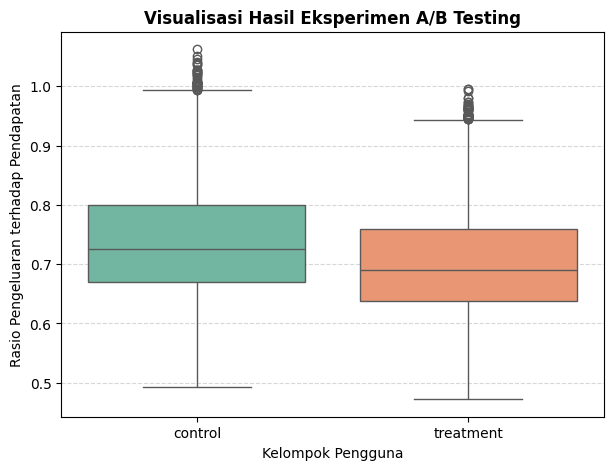

In [8]:
# Membuat grafik Box Plot untuk visualisasi laporan
plt.figure(figsize=(7, 5))
sns.boxplot(x='group', y='Expense_Income_Ratio', data=df_ab, palette='Set2')
plt.title('Visualisasi Hasil Eksperimen A/B Testing', fontsize=12, fontweight='bold')
plt.xlabel('Kelompok Pengguna', fontsize=10)
plt.ylabel('Rasio Pengeluaran terhadap Pendapatan', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()